# Nama: Ergie Restu Dwi Maulana
# Nim: 23.11.5505


# Inisialisasi dan Import Library

In [4]:
# ============================================================
# TAHAP 1: IMPORT LIBRARIES
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

print("Library berhasil di-import.")

Library berhasil di-import.


# Loading Dataset

In [5]:
# ============================================================
# TAHAP 2: DATA INGESTION
# ============================================================
# Pastikan file train.csv sudah kamu upload di folder samping
df = pd.read_csv('train.csv')

print(f"Dataset berhasil dimuat dengan {df.shape[0]} baris dan {df.shape[1]} kolom.")
df.head()

Dataset berhasil dimuat dengan 1460 baris dan 81 kolom.


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


# Eksplorasi Data Awal (EDA)

In [6]:
# ============================================================
# TAHAP 3: EXPLORATORY DATA ANALYSIS (IDENTIFIKASI DATA)
# ============================================================
print("--- Mengecek Missing Values ---")
print(df[['LotArea', 'SalePrice']].isnull().sum())

print("\n--- Deskripsi Statistik Variabel Utama ---")
print(df[['LotArea', 'SalePrice']].describe())

--- Mengecek Missing Values ---
LotArea      0
SalePrice    0
dtype: int64

--- Deskripsi Statistik Variabel Utama ---
             LotArea      SalePrice
count    1460.000000    1460.000000
mean    10516.828082  180921.195890
std      9981.264932   79442.502883
min      1300.000000   34900.000000
25%      7553.500000  129975.000000
50%      9478.500000  163000.000000
75%     11601.500000  214000.000000
max    215245.000000  755000.000000


# Visualisasi Distribusi (Grafik 1)

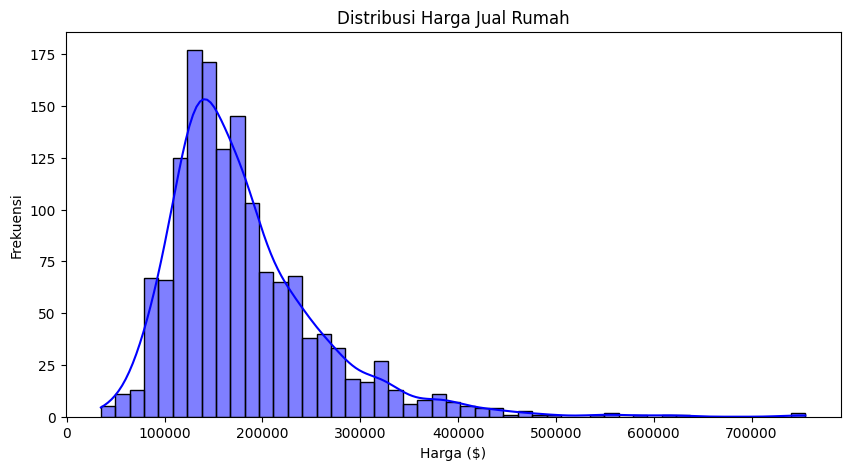

In [7]:
# ============================================================
# TAHAP 4: VISUALISASI DISTRIBUSI TARGET (SALE PRICE)
# ============================================================
plt.figure(figsize=(10, 5))
sns.histplot(df['SalePrice'], kde=True, color='blue')
plt.title('Distribusi Harga Jual Rumah')
plt.xlabel('Harga ($)')
plt.ylabel('Frekuensi')
plt.show()

# Data Cleaning & Outlier Handling

In [8]:
# ============================================================
# TAHAP 5: DATA PREPROCESSING (PEMBERSIHAN OUTLIER)
# ============================================================
# Kita batasi data agar tidak ada luas tanah yang terlalu ekstrem (pencilan)
df_filtered = df[(df['LotArea'] < 25000) & (df['SalePrice'] < 400000)]

print(f"Data asli: {len(df)}")
print(f"Data setelah difilter: {len(df_filtered)}")

Data asli: 1460
Data setelah difilter: 1403


# Visualisasi Korelasi (Grafik 2)

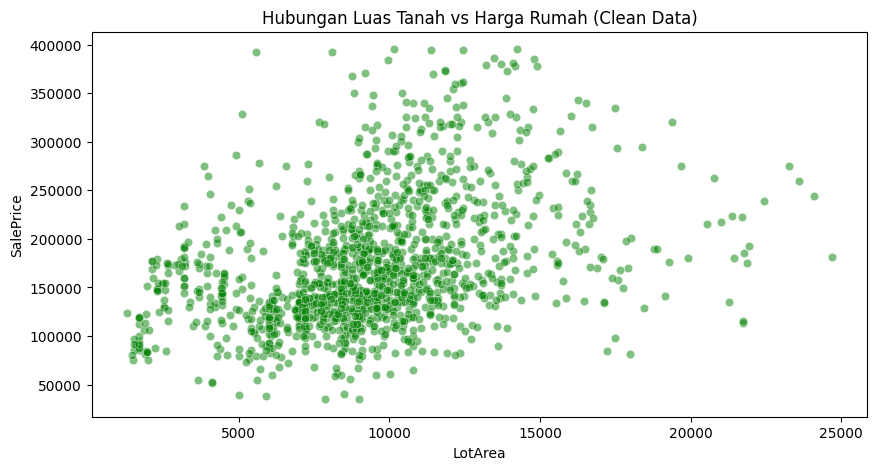

In [9]:
# ============================================================
# TAHAP 6: ANALISIS HUBUNGAN VARIABEL (SCATTER PLOT)
# ============================================================
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_filtered, x='LotArea', y='SalePrice', color='green', alpha=0.5)
plt.title('Hubungan Luas Tanah vs Harga Rumah (Clean Data)')
plt.show()

# Splitting Dataset

In [10]:
# ============================================================
# TAHAP 7: DATA SPLITTING (TRAIN & TEST SET)
# ============================================================
X = df_filtered[['LotArea']]
y = df_filtered['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data berhasil dibagi: 80% Training dan 20% Testing.")

Data berhasil dibagi: 80% Training dan 20% Testing.


# Membangun Model Linear Regression

In [11]:
# ============================================================
# TAHAP 8: MODEL BUILDING (LINEAR REGRESSION)
# ============================================================
model = LinearRegression()
model.fit(X_train, y_train)

print("Model Linear Regression berhasil dilatih.")

Model Linear Regression berhasil dilatih.


# Prediksi dan Uji Akurasi

In [12]:
# ============================================================
# TAHAP 9: MODEL EVALUATION
# ============================================================
y_pred = model.predict(X_test)

# Menghitung Metrik
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"Akurasi Model (R2 Score): {r2:.4f}")
print(f"Error Rata-rata (MAE)  : ${mae:,.2f}")
print(f"RMSE                   : ${rmse:,.2f}")

Akurasi Model (R2 Score): 0.1506
Error Rata-rata (MAE)  : $45,827.48
RMSE                   : $59,520.90


# Visualisasi Garis Regresi Akhir

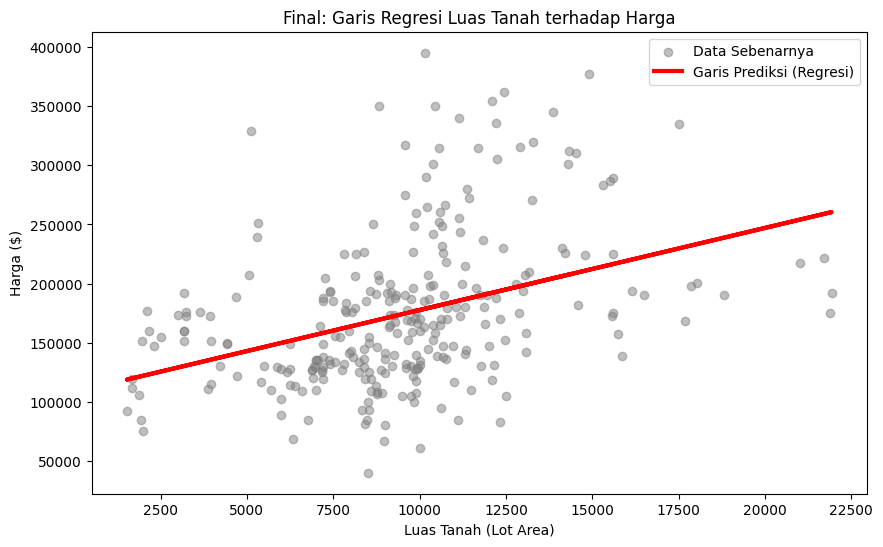

In [13]:
# ============================================================
# TAHAP 10: VISUALISASI HASIL REGRESI
# ============================================================
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='gray', alpha=0.5, label='Data Sebenarnya')
plt.plot(X_test, y_pred, color='red', linewidth=3, label='Garis Prediksi (Regresi)')
plt.title('Final: Garis Regresi Luas Tanah terhadap Harga')
plt.xlabel('Luas Tanah (Lot Area)')
plt.ylabel('Harga ($)')
plt.legend()
plt.show()

# Simulasi Input Manual

In [14]:
# ============================================================
# TAHAP 11: PREDIKSI INTERAKTIF
# ============================================================
input_luas = 12000 # Coba ganti angka ini bebas
hasil = model.predict([[input_luas]])

print(f"--- SIMULASI PREDIKSI ---")
print(f"Jika Luas Tanah anda: {input_luas} sqft")
print(f"Maka perkiraan harga rumah: ${hasil[0]:,.2f}")

--- SIMULASI PREDIKSI ---
Jika Luas Tanah anda: 12000 sqft
Maka perkiraan harga rumah: $191,475.92


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
